## Importation des bibliothèques nécessaires pour le projet

In [32]:
import numpy as np
from enum import Enum
import random
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

## Question 1

In [33]:
 #On définit deux types de votes où les votes par approbations sont définit par 1 et les ordres_totaux par 0.
class TypeDeVote(Enum):
    APPROBATION = 0
    ORDRE_TOTAUX = 1

In [34]:
def generer_approbation_profil(n, m, polarisation = 0.0, bruit = 0.05): # n = nombre de votantes, m = nombre de candidates, bruit = probabilité de modifier un vote (erreur aléatoire)
#on créer un tableau de taille m (pour les m candidates) avec des 0 et 1 mis de manière aléatoire. Le a représente un vote avec par exemple dans le cas des vote par approbation 1 qui dit que la votante approuve la candidate, 0 sinon.
    a = np.random.randint(0, 2, m)
    # C'est le vote opposé de a. Si la votante approuve la candidate dans son a, alors a_barre est le vote qui ne l'approuve pas
    a_barre = 1 - a
# On créer la liste profil qui va donc contenir tous les votes
    profil = []
#on fait une boucle sur les n votantes. L'idée est que pour chaque votante : 
    for _ in range(n):
# On tire un nombre entre 0 et 1 si on est dans le cas de non polarisation
        if np.random.rand() < (1-polarisation):
            # avec le a.copy, la votante suit le vote de préférences
            vote = a.copy()
        #sinon on est dans le cas polarisé
        else:
            #on choisit aléatoirement entre les deux groupes possible (approuve ou n'approuve pas)
            if np.random.choice([True, False]):
                # le groupe opposé vote donc l'inverse
                vote = a_barre.copy()
            else:
                #sinon, la votante reste sur le vote originale
                vote = a.copy()
        
        # ajout du bruit. On parcours chaque candidate
        for j in range(m):
        #Avec une probabilité bruit, on modifie le vote si on a une erreur
            if np.random.rand() < bruit:
                #Ainsi si on a une erreur, on inverse la valeure. Ainsi, 1 devient 0 et 0 devient 1
                vote[j] = 1 - vote[j]
        # On ajoute le vote de la votante à la liste
        profil.append(vote)
    #On créer notre matrice avec en ligne les votantes et en colonne les candidates. 
    return np.array(profil)

# Exemple :
#Très peu polarisé :
if __name__ == "__main__":
    # Ici, toutes les votantes pareil car 0 polarisation et pas de bruit donc pas d'erreur
    p = generer_approbation_profil(n=10, m=5, polarisation=0.0, bruit=0)
    print("Profil très peu polarisé")
    print(p)

#Très polarisé :
if __name__ == "__main__":
    # Ici, on a une forte polarisation donc les votantes sont séparés en 2 groupes opposé. 
    p = generer_approbation_profil(n=10, m=5, polarisation=1.0, bruit=0)
    print("Profil très polarisé")
    print(p)


Profil très peu polarisé
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Profil très polarisé
[[1 0 1 1 1]
 [1 0 1 1 1]
 [1 0 1 1 1]
 [1 0 1 1 1]
 [0 1 0 0 0]
 [1 0 1 1 1]
 [1 0 1 1 1]
 [1 0 1 1 1]
 [0 1 0 0 0]
 [0 1 0 0 0]]


## Question 2

In [35]:
def generer_ordre_profil(n, m, polarisation = 0.0, bruit = 0.00): # n = nombre de votantes, m = nombre de candidates, bruit = probabilité de perturber un classement
#créer une permutation aléatoire entre 1 et m. Représente donc un classement de préférences. 
    ordre = np.random.permutation(m)
    #inverse l'ordre. C'est le classement opposé
    ordre_barre = ordre[::-1]
    #liste vide pour enregistré les classements
    profil = []
    #Pour chaque votante, on génère un classement
    for _ in range(n):
        #Dans le cas de non polarisation 
        if np.random.rand() < (1-polarisation):
            #la votante suit le classement de référence
            vote = ordre.copy()
        #Sinon, on est dans le cas polarisé
        else:
            #On choisit aléatoirement un groupe. La votante fera donc partie soit du groupe qui approuve la candidate, soit du groupe qui ne l'approuve pas dans le cas des préférences par approbation
            if np.random.choice([True, False]):
                # Son vote et elle se situe donc dans le groupe opposé.
                vote = ordre_barre.copy()
            else:
                #Sinon elle se situe dans le groupe de base. 
                vote = ordre.copy()

        if np.random.rand() < bruit:
            # On choisit 2 positions différentes aux hasards
            i, j = np.random.choice(m, 2, replace=False)
            #on échange ces deux éléments
            vote[i], vote[j] = vote[j], vote[i]
        #Ajoute le classement de la votante
        profil.append(vote)

    return np.array(profil)

# Exemple :
#Très peu polarisé :
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=0.0, bruit=0)
    print("Profil très peu polarisé")
    print(p)

#Très polarisé :
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=1.0, bruit=0)
    print("Profil très polarisé")
    print(p)


Profil très peu polarisé
[[4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]
 [4 2 0 3 1]]
Profil très polarisé
[[4 1 0 2 3]
 [4 1 0 2 3]
 [3 2 0 1 4]
 [4 1 0 2 3]
 [3 2 0 1 4]
 [3 2 0 1 4]
 [3 2 0 1 4]
 [3 2 0 1 4]
 [4 1 0 2 3]
 [4 1 0 2 3]]


In [36]:
#Pour appeler les prochains exemples, il sera plus simple d'avoir cette fonction qui nous permettra de générer un profil en fonction du type de vote que l'on souhaite.
def generer_profil(type_de_vote, n, m, polarisation, bruit=0.0):
    match type_de_vote:
        #si TypeDeVote = APPROBATION, alors on génère un profil d'approbation
        case TypeDeVote.APPROBATION:
            return generer_approbation_profil(n, m, polarisation, bruit)
        #si TypeDeVote = ORDRE_TOTAUX, alors on génère un profil d'ordres totaux
        case TypeDeVote.ORDRE_TOTAUX:
            return generer_ordre_profil(n, m, polarisation, bruit)

## Question 3

In [37]:
#fonction qui nous dit combien de votantes préfèrent la candidate k à la candidate l en fonction du type de vote (definit par notre enumération)
def nbr_votantes_pref(profil, k, l, type_de_vote):
    """Étant donné un profil et deux candidates d'indice k et l, cette méthode 
    retourne de nombre de votantes qui préfèrent ck à cl, étant donné le type de vote.
    """
    #equivalent d'un switch en java
    match type_de_vote:
        #Cas où on est le vote par approbation
        case TypeDeVote.APPROBATION:
            #on compte les votantes qui approuvent k mais n'approuvent pas l. On compte combien de fois c'est vrai
            return np.sum((profil[:,k] == 1) & (profil[:,l] == 0))
        #Cas où on est dans le vote par ordre totaux
        case TypeDeVote.ORDRE_TOTAUX:
            n_kl = 0
            #Pour chaque votante
            for vote in profil:
                #on regarde la position de la candidate k et de la candidate l pour la votante 
                position_k = np.where(vote == k)[0][0]
                position_l = np.where(vote == l)[0][0]
                if position_k < position_l:
                    #on incrément si k est préféré à l
                    n_kl += 1
            # On retourne le nombre totale de votantes préférant k à l 
            return n_kl


def diff_absolue(profil, k, l, type_de_vote):
    # On calcule ici combien de votante préfèrent k à l et combien de votantes préfèrent l à k
    n_kl = nbr_votantes_pref(profil, k, l, type_de_vote)
    n_lk = nbr_votantes_pref(profil, l, k, type_de_vote)
    #On retourne la différence en valeur absolue pour avoir toujours une différence positive entre ces préférences
    return abs(n_kl - n_lk)


def ensemble_des_diff_absolue(profil, type_de_vote):
    # n = nombre de votantes(ligne), m = nombre de candidates(colonne)
    n, m = profil.shape
    d_valeurs = []
    #Pour toutes les paires de candidates
    for k in range(m):
        for l in range(k+1, m):
            #On calcule la différence entre chaque paire de candidates
            d = diff_absolue(profil, k, l, type_de_vote)
            #on ajoute la valeur dans notre liste
            d_valeurs.append(d)
            #on retourne le tableau des différences
    return np.array(d_valeurs)


def ensemble_des_diff_absolue_approbation(profil):
    return ensemble_des_diff_absolue(profil, TypeDeVote.APPROBATION)


def ensemble_des_diff_absolue_ordre_totaux(profil):
        return ensemble_des_diff_absolue(profil, TypeDeVote.ORDRE_TOTAUX)


#Exemple : 
if __name__ == "__main__":
    p = generer_approbation_profil(n=10, m=5, polarisation=1.0)
    print(ensemble_des_diff_absolue_approbation(p))

        
#Exemple : 
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=1.0)
    print(ensemble_des_diff_absolue_ordre_totaux(p))
            


[1 2 2 0 1 1 1 0 2 2]
[4 4 4 4 4 4 4 4 4 4]


## Question 5

In [38]:
#On peut maintenant calculer la valeur de Phi2 pour un profil donné et un type de vote spécifié.
def phi2(profil, type_de_vote):
    # on récupère le nombre de votantes et de candidates à partir de la taille du profil
    n, m = profil.shape
    # on calcule l'ensemble des différences absolues pour le profil et le type de vote donné
    d_valeurs = ensemble_des_diff_absolue(profil, type_de_vote)
    # on retourne la valeur de Phi2 en utilisant la formule donnée. 
    return 1 - np.sum(d_valeurs) / (n * (m*(m-1)))


# Exemple :

if __name__ == "__main__":
    for type_de_vote in TypeDeVote:
        print(f"Type de vote: {type_de_vote.name}")
        profil = generer_profil(type_de_vote=type_de_vote, n=10, m=5, polarisation=0.0)
        print("Phi2 approbation pour profil non polarise:", phi2(profil, TypeDeVote.APPROBATION))

if __name__ == "__main__":
    for type_de_vote in TypeDeVote:
        print(f"Type de vote: {type_de_vote.name}")
        profil = generer_profil(type_de_vote=type_de_vote, n=10, m=5, polarisation=1.0)
        print("Phi2 approbation pour profil polarise:", phi2(profil, TypeDeVote.APPROBATION))

Type de vote: APPROBATION
Phi2 approbation pour profil non polarise: 0.8
Type de vote: ORDRE_TOTAUX
Phi2 approbation pour profil non polarise: 0.95
Type de vote: APPROBATION
Phi2 approbation pour profil polarise: 0.94
Type de vote: ORDRE_TOTAUX
Phi2 approbation pour profil polarise: 0.95


## Question 6

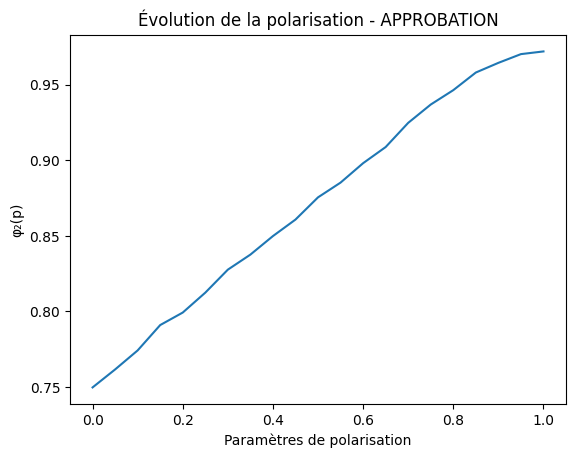

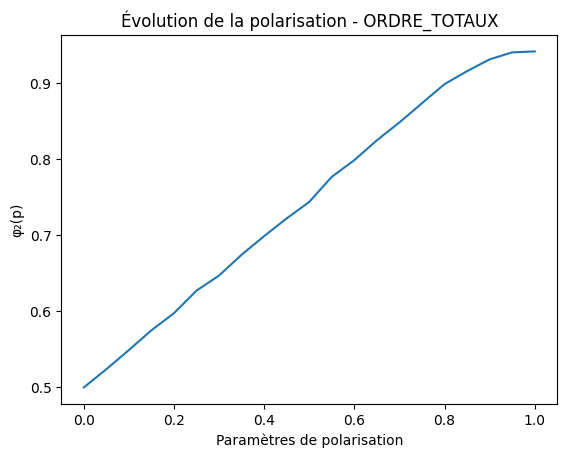

In [39]:
# Générer des profils d'approbation et d'ordre pour différentes valeurs de polarisation :
def simuler_phi2(type_de_vote, n, m, repetitions = 1000):
    # on crée une liste de valeurs de polarisation allant de 0 à 1 avec un pas de 0.05
    p_valeurs = np.linspace(0, 1, 21)
    # on crée une liste pour stocker les valeurs moyennes de phi2 pour chaque valeur de polarisation
    phi_moyen = []

    for p in p_valeurs:
        valeurs = []
        for _ in range(repetitions):
            # on génère un profil pour le type de vote, le nombre de votantes, le nombre de candidates et la polarisation donnée
            profil = generer_profil(type_de_vote=type_de_vote, n=n, m=m, polarisation=p)
            # on calcule la valeur de phi2 pour ce profil et ce type de vote, et on l'ajoute à la liste des valeurs
            phi = phi2(profil, type_de_vote)
            valeurs.append(phi)
        # on calcule la moyenne de phi2 pour les profils générés à cette valeur de polarisation et on l'ajoute à la liste des moyennes
        phi_moyen.append(np.mean(valeurs))
    # on retourne les listes de valeurs de polarisation et de phi2 moyen
    return p_valeurs, phi_moyen


n = 50
m = 5

for type_de_vote in TypeDeVote:
    # on simule les valeurs de phi2 pour différentes valeurs de polarisation et on les stocke dans p_valeurs et phi_moyen
    p_valeurs, phi_moyen = simuler_phi2(type_de_vote=type_de_vote, n=n, m=m)
    # on trace l'évolution de phi2 en fonction de la polarisation pour ce type de vote
    plt.plot(p_valeurs, phi_moyen)
    plt.xlabel('Paramètres de polarisation')
    plt.ylabel('φ₂(p)')
    plt.title(f'Évolution de la polarisation - {type_de_vote.name}')
    plt.show()

## Question 8 : 

In [40]:
def distance_hamming(a, b):
    # a ^ b est le XOR bit à bit de a et b: contient des 1 aux positions où a et b diffèrent, et des 0 aux positions où a et b sont identiques.
    return int(np.sum(a ^ b))

In [41]:
def distance_spearman(a, b):
    # La distance de Spearman est la somme des différences absolues entre les positions des éléments dans les deux classements.
    return np.sum(abs(np.subtract(a, b)))

## Question 12

In [42]:
# Calcul du consensus pour les votes par approbation
# On sépare dans deux fonctions le calcul du consensus et de u_1 pour faciliter les questions suivantes. 
def calcul_consensus_approbation(profil):
    # on récupère le nombre de votantes et de candidates à partir de la taille du profil
    n,m = profil.shape
    # on initialise le consensus avec des 0 pour chaque candidate
    consensus = [0]*m

    for col in range(m):
        # on calcule la somme des votes pour la candidate col. Cela correspond au nombre de votantes qui approuvent cette candidate
        somme = sum(vote[col] for vote in profil)

        # Si la somme est supérieure à n/2, cela signifie que plus de la moitié des votantes approuvent cette candidate, donc on met 1 dans le consensus pour cette candidate.
        if somme > n/2: 
            consensus[col] = 1
        # Si la somme est inférieure à n/2, cela signifie que moins de la moitié des votantes approuvent cette candidate, donc on met 0 dans le consensus pour cette candidate.
        elif somme < n/2: 
            consensus[col] = 0  
        # Si la somme est exactement égale à n/2, cela signifie que la moitié des votantes approuvent cette candidate et l'autre moitié ne l'approuve pas. 
        # Dans ce cas, on peut choisir aléatoirement entre 0 et 1 pour le consensus de cette candidate.
        else:
            consensus[col] = random.randint(0,1) 

    # on retourne le consensus calculé
    return consensus


# L'utilité u_1 est définie comme la somme des distances de Hamming entre les votes individuels et le consensus.   
def calcul_u1_approbation(profil):
    consensus = calcul_consensus_approbation(profil)
    u1 = sum([distance_hamming(vote, consensus) for vote in profil])
    return u1

# Exemple d'utilisation : 
profil = generer_approbation_profil(n=6, m=10, polarisation=0.3)
consensus = calcul_consensus_approbation(profil=profil)
u1 = calcul_u1_approbation(profil=profil)
print("profil:\n", profil)
print("consensus:", consensus)
print("u1:", u1)

profil:
 [[1 1 0 0 0 1 1 1 0 0]
 [1 1 0 1 0 1 0 1 0 0]
 [1 1 0 0 0 0 0 1 0 0]
 [0 0 1 1 1 0 1 0 1 1]
 [1 1 0 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 0 0]]
consensus: [1, 1, 0, 0, 0, 1, 0, 1, 0, 0]
u1: 13


In [43]:
# Calcul du consensus pour les votes par ordres totaux
# On sépare dans deux fonctions le calcul du consensus et de u_1 pour faciliter les questions suivantes. 
def calcul_consensus_ordre(profil):

    # on récupère le nombre de votantes et de candidates à partir de la taille du profil
    n, m = profil.shape

    # on crée une matrice de poids de taille m x m pour stocker les poids associés à chaque candidat et à chaque rang possible
    poids = np.zeros((m,m))
    for candidat in range(m):
        for rang_possible in range(m):
            # on calcule le poids pour le candidat et le rang possible en sommant les distances absolues entre la position du candidat dans chaque vote et le rang possible
            pds = 0
            for vote in profil:
                index = int(np.where(vote == candidat)[0][0])
                absolue = abs(index - rang_possible)
                pds += absolue
            # on stocke le poids calculé dans la matrice de poids à la position correspondant au candidat et au rang possible
            poids[candidat][rang_possible] = pds

    # on utilise l'algorithme de l'affectation linéaire (Hungarian algorithm) pour trouver l'affectation optimale des candidats aux rangs qui minimise le poids total.
    # C'est la méthode recommandée dans l'énoncé
    candidate_ind, rank_ind = linear_sum_assignment(poids)

    # on initialise le consensus avec des 0 pour chaque candidate
    consensus = [0]*m
    for i in range(m):
        # on remplit le consensus en assignant à chaque rang le candidat correspondant à l'affectation optimale trouvée par l'algorithme de l'affectation linéaire.
        consensus[rank_ind[i]] = int(candidate_ind[i])

    # on retourne le consensus calculé
    return consensus


# u_1 est définie comme la somme des distances de Spearman entre les votes individuels et le consensus.
def calcul_u1_ordre(profil):
    consensus = calcul_consensus_ordre(profil=profil)
    u1 = sum([distance_spearman(vote, consensus) for vote in profil])

    # on retourne l'utilité u1 calculée
    return u1

# Exemple d'utilisation :
profil = generer_ordre_profil(n=6, m=10, polarisation=0.4)
consensus = calcul_consensus_ordre(profil=profil)
u1 = calcul_u1_ordre(profil=profil)
print("profil:\n", profil)
print("consensus:", consensus)
print("u1:", u1)


profil:
 [[5 1 3 6 4 2 7 8 0 9]
 [5 1 3 6 4 2 7 8 0 9]
 [5 1 3 6 4 2 7 8 0 9]
 [5 1 3 6 4 2 7 8 0 9]
 [9 0 8 7 2 4 6 3 1 5]
 [5 1 3 6 4 2 7 8 0 9]]
consensus: [5, 1, 3, 6, 4, 2, 7, 8, 0, 9]
u1: 26


## Question 13

In [44]:
# On calcule u_2 pour les votes par approbation en utilisant une approche d'approximation basée sur la méthode de k-means. 
def calcul_u2_approbation(profil, max_iter=10_000):

    # on récupère le nombre de votantes et de candidates à partir de la taille du profil
    n, m = profil.shape
    
    # on initialise aléatoirement deux centres de cluster a1 et a2, qui représentent les deux groupes de votantes dans le cas polarisé. 
    a1 = np.random.randint(0, 2, size=m) 
    a2 = np.random.randint(0, 2, size=m) 

    for i in range(max_iter):

        # on crée deux clusters vides pour séparer les votantes en fonction de leur proximité avec les centres a1 et a2
        cluster1 = []
        cluster2 = []

        for votes in profil : 
            # on calcule la distance de Hamming entre les votes de chaque votante et les centres a1 et a2, et on les affecte au cluster correspondant au centre le plus proche.
            if distance_hamming(votes, a1) < distance_hamming(votes, a2) : 
                cluster1.append(votes)
            else : 
                cluster2.append(votes)

        # on calcule les nouveaux centres de cluster a1BIS et a2BIS en prenant le consensus de chaque cluster. 
        # Si un cluster est vide, on réinitialise aléatoirement le centre de ce cluster.
        if len(cluster1) > 0:
            a1BIS = calcul_consensus_approbation(np.array(cluster1))
        else:
            a1BIS = np.random.randint(0, 2, size=m)

        if len(cluster2) > 0:
            a2BIS = calcul_consensus_approbation(np.array(cluster2))
        else:
            a2BIS = np.random.randint(0, 2, size=m)

        # on vérifie si les centres de cluster ont convergé (c'est-à-dire s'ils n'ont pas changé par rapport à l'itération précédente). 
        # Si c'est le cas, on calcule u2 et on le retourne. Sinon, on met à jour les centres de cluster pour la prochaine itération.
        if np.array_equal(a1, a1BIS) and np.array_equal(a2, a2BIS):
            a1 = a1BIS 
            a2 = a2BIS
            u2 = sum([distance_hamming(vote, a1) for vote in cluster1]) + sum([distance_hamming(vote, a2) for vote in cluster2])
            return int(u2)            
        else : 
            a1 = a1BIS 
            a2 = a2BIS

    # Si on atteint le nombre maximum d'itérations sans convergence, on renvoie une erreur.
    raise ValueError()


# Exemple d'utilisation :
profil = generer_approbation_profil(n=6, m=10, polarisation=0.0)
print("Profil:\n", profil)
u1 = calcul_u1_approbation(profil)
u2 = calcul_u2_approbation(profil)
print("u1:", u1)
print("u2:", u2)
print("u1-u2:", u1-u2)

Profil:
 [[1 1 1 0 0 1 0 0 0 0]
 [1 1 1 0 0 1 0 0 0 0]
 [1 1 1 0 1 1 0 0 0 0]
 [1 1 1 0 0 1 0 0 0 0]
 [1 1 1 0 0 1 0 0 0 0]
 [1 1 1 0 0 1 0 0 1 0]]
u1: 2
u2: 1
u1-u2: 1


In [45]:
# On calcule u_2 pour les votes par ordres totaux en utilisant une approche d'approximation basée sur la méthode de k-means. 
def calcul_u2_ordre(profil, max_iter=10_000):
    
    # on récupère le nombre de votantes et de candidates à partir de la taille du profil
    n, m = profil.shape

    # on initialise aléatoirement deux centres de cluster a1 et a2, qui représentent les deux groupes de votantes dans le cas polarisé. 
    # On a bien que les centroides a1 et a2 correspondent à des classements de référence.
    a1 = np.arange(m)
    np.random.shuffle(a1)

    a2 = np.arange(m)
    np.random.shuffle(a2)

    for i in range(max_iter):

        # on crée deux clusters vides pour séparer les votantes en fonction de leur proximité avec les centres a1 et a2
        cluster1 = []
        cluster2 = []

        for votes in profil : 
            # on calcule la distance de Spearman entre les votes de chaque votante et les centres a1 et a2, et on les affecte au cluster correspondant au centre le plus proche.
            if distance_spearman(votes, a1) < distance_spearman(votes, a2) : 
                cluster1.append(votes)
            else : 
                cluster2.append(votes)

        # on calcule les nouveaux centres de cluster a1BIS et a2BIS en prenant le consensus de chaque cluster.
        # Si un cluster est vide, on réinitialise aléatoirement le centre de ce cluster.
        if len(cluster1) > 0:
            a1BIS = calcul_consensus_ordre(np.array(cluster1))
        else:
            a1BIS = a1
            np.random.shuffle(a1BIS)

        if len(cluster2) > 0:
            a2BIS = calcul_consensus_ordre(np.array(cluster2))
        else:
            a2BIS = a2
            np.random.shuffle(a2BIS)

        # on vérifie si les centres de cluster ont convergé (c'est-à-dire s'ils n'ont pas changé par rapport à l'itération précédente). 
        # Si c'est le cas, on calcule u2 et on le retourne. Sinon, on met à jour les centres de cluster pour la prochaine itération.
        if np.array_equal(a1, a1BIS) and np.array_equal(a2, a2BIS):
            a1 = a1BIS 
            a2 = a2BIS
            u2 = sum([distance_spearman(vote, a1) for vote in cluster1]) + sum([distance_spearman(vote, a2) for vote in cluster2])
            return int(u2)            
        else : 
            a1 = a1BIS 
            a2 = a2BIS

    # Si on atteint le nombre maximum d'itérations sans convergence, on renvoie une erreur.
    raise ValueError()

# Exemple d'utilisation :
profil = generer_ordre_profil(n=6, m=10, polarisation=1.0)
print("Profil:\n", profil)
u1 = calcul_u1_ordre(profil)
u2 = calcul_u2_ordre(profil)
print("u1:", u1)
print("u2:", u2)
print("u1-u2:", u1-u2)

Profil:
 [[3 6 1 5 9 0 2 4 8 7]
 [3 6 1 5 9 0 2 4 8 7]
 [7 8 4 2 0 9 5 1 6 3]
 [3 6 1 5 9 0 2 4 8 7]
 [3 6 1 5 9 0 2 4 8 7]
 [3 6 1 5 9 0 2 4 8 7]]
u1: 42
u2: 0
u1-u2: 42


## Question 14 : 

In [46]:
def phi_hamming(profil):
    # n = nombre de votantes (ligne), m = nombre de candidate (colonne)
    n, m = profil.shape
    # Si n = 0 ou m = 0 alors on a une erreur car on ne peut pas diviser par 0 dans la formule d'où le ValueError
    if n == 0 or m == 0:
        raise ValueError()
    #On calcule u1 et u2 dans le cas des approbations car distance Hamming s'applique dans ce cas là
    u1_h = calcul_u1_approbation(profil=profil)
    u2_h = calcul_u2_approbation(profil=profil)
    #la formule donné dans l'énoncé
    phi = 2 * (u1_h-u2_h) / (n*m)

    return phi

In [47]:
def phi_spearman(p):
    # n = nombre de votantes (ligne), m = nombre de candidate (colonne)
    n, m = p.shape
    # Si n = 0 ou m = 0 alors on a une erreur car on ne peut pas diviser par 0 dans la formule d'où le ValueError
    if n == 0 or m == 0:
        raise ValueError()
    #On calcule u1 et u2 dans le cas des ordres totaux car distance Spearman s'applique dans ce cas là
    u1_h = calcul_u1_ordre(profil=p)
    u2_h = calcul_u2_ordre(profil=p)
    #la formule donné dans l'énoncé
    phi = 4 * (u1_h-u2_h) / (n*m*m)

    return phi

### Test

Ici, on a une polarisation de 0.9 soit proche de 1. On devrait donc obtenir un 𝛟 proche de 1.

In [48]:
p = generer_approbation_profil(20, 6, 0.9)
print(phi_hamming(p))

0.7333333333333333


Ici, on a une polarisation très faible (de 0.1). On devrait donc obtenir un 𝛟 proche de 0.

In [49]:
p = generer_approbation_profil(20, 6, 0.1)
print(phi_hamming(p))

0.2


In [50]:
p = generer_ordre_profil(20, 6, 1.0)
print(phi_spearman(p))

0.6222222222222222


## Question 15 : 

### Évolution des mesures 𝜑_dh

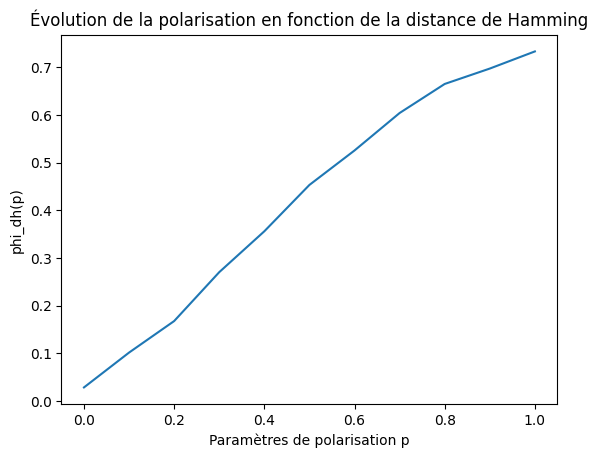

In [51]:
#nombre de répétitions pour chaque niveau de polarisation utilisé afin de faire une moyenne stable
nb_tests = 100
#les différentes valeurs de polarisation possible en décimale (O = pas polarisé, 1 = polarisé)
niveaux_polarisation = [k/10 for k in range (11)]

phi = [] #on cree une liste pour pouvoir enregistrer les différentes valeurs données
#pour chaque niveau de polarisation
for polarisation in niveaux_polarisation:
    moyenne = 0
    for n in range (nb_tests):
        #on génère un profil avec 20 votantes, 6 candidate et le niveau de polarisation donné dans la boucle
        p = generer_approbation_profil(20, 6, polarisation)
        #on calcul phi_hamming
        moyenne += phi_hamming(p)
        #on ajoute cette valeure par rapport au nombre de test que l'on a et on ajoute ce resultat dans notre liste phi
    phi.append(moyenne/nb_tests)
#on trace la graphique grâce à la bibliothèque matplotlib
plt.plot(niveaux_polarisation, phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_dh(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Hamming")
plt.show()

### Évolution des mesures 𝜑_ds

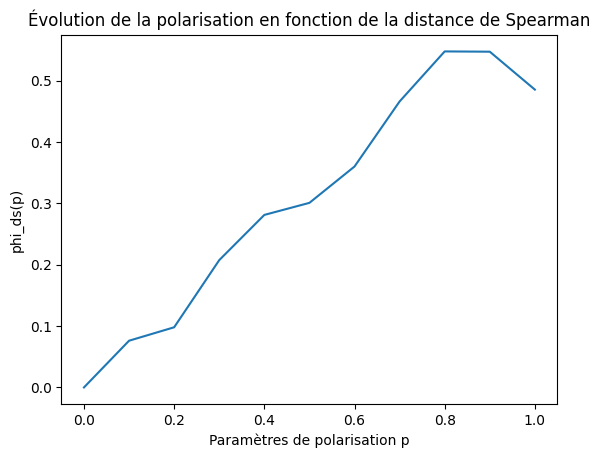

In [52]:
#nombre de répétitions pour chaque niveau de polarisation utilisé afin de faire une moyenne stable
nb_tests = 100
#les différentes valeurs de polarisation possible en décimale (O = pas polarisé, 1 = polarisé)
niveaux_polarisation = [k/10 for k in range (11)]

phi = [] #on cree une liste pour pouvoir enregistrer les différentes valeurs données
#pour chaque niveau de polarisation
for polarisation in niveaux_polarisation:
    moyenne = 0
    for n in range(nb_tests):
        #on génère un profil avec 20 votantes, 6 candidate et le niveau de polarisation donné dans la boucle
        p = generer_ordre_profil(20, 6, polarisation)
        #on calcul phi_spearman
        moyenne += phi_spearman(p)
    #on ajoute cette valeure par rapport au nombre de test que l'on a et on ajoute ce resultat dans notre liste phi
    phi.append(moyenne/nb_tests)
#on trace la graphique grâce à la bibliothèque matplotlib
plt.plot(niveaux_polarisation, phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_ds(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Spearman")
plt.show()